In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

In [2]:
# Load Dataset
df = pd.read_csv('heart_attack_prediction_dataset.csv')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [5]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [13]:
columns_to_drop = ['Hemisphere', 'Patient ID', 'Continent', 'Patient ID', 'Family History', 'Sex', 'Country', 'Income', 'Diet', 'Obesity', 'Smoking', 'Blood Pressure', 'Alcohol Consumption', 'Exercise Hours Per Week','Previous Heart Problems', 'Medication Use', 'Sedentary Hours Per Day','Physical Activity Days Per Week', 'Sleep Hours Per Day']
df.drop(columns_to_drop, axis=1, inplace=True)
df.head()

,Age,Cholesterol,Heart Rate,Diabetes,Stress Level,BMI,Triglycerides,Heart Attack Risk
0,67,208,72,0,9,31.251233,286,0
1,21,389,98,1,1,27.194973,235,0
2,21,324,72,1,9,28.176571,587,0
3,84,383,73,1,9,36.464704,378,0
4,66,318,93,1,6,21.809144,231,0


In [14]:
x = df.drop('Heart Attack Risk', axis = 1)
y = df['Heart Attack Risk']

In [15]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

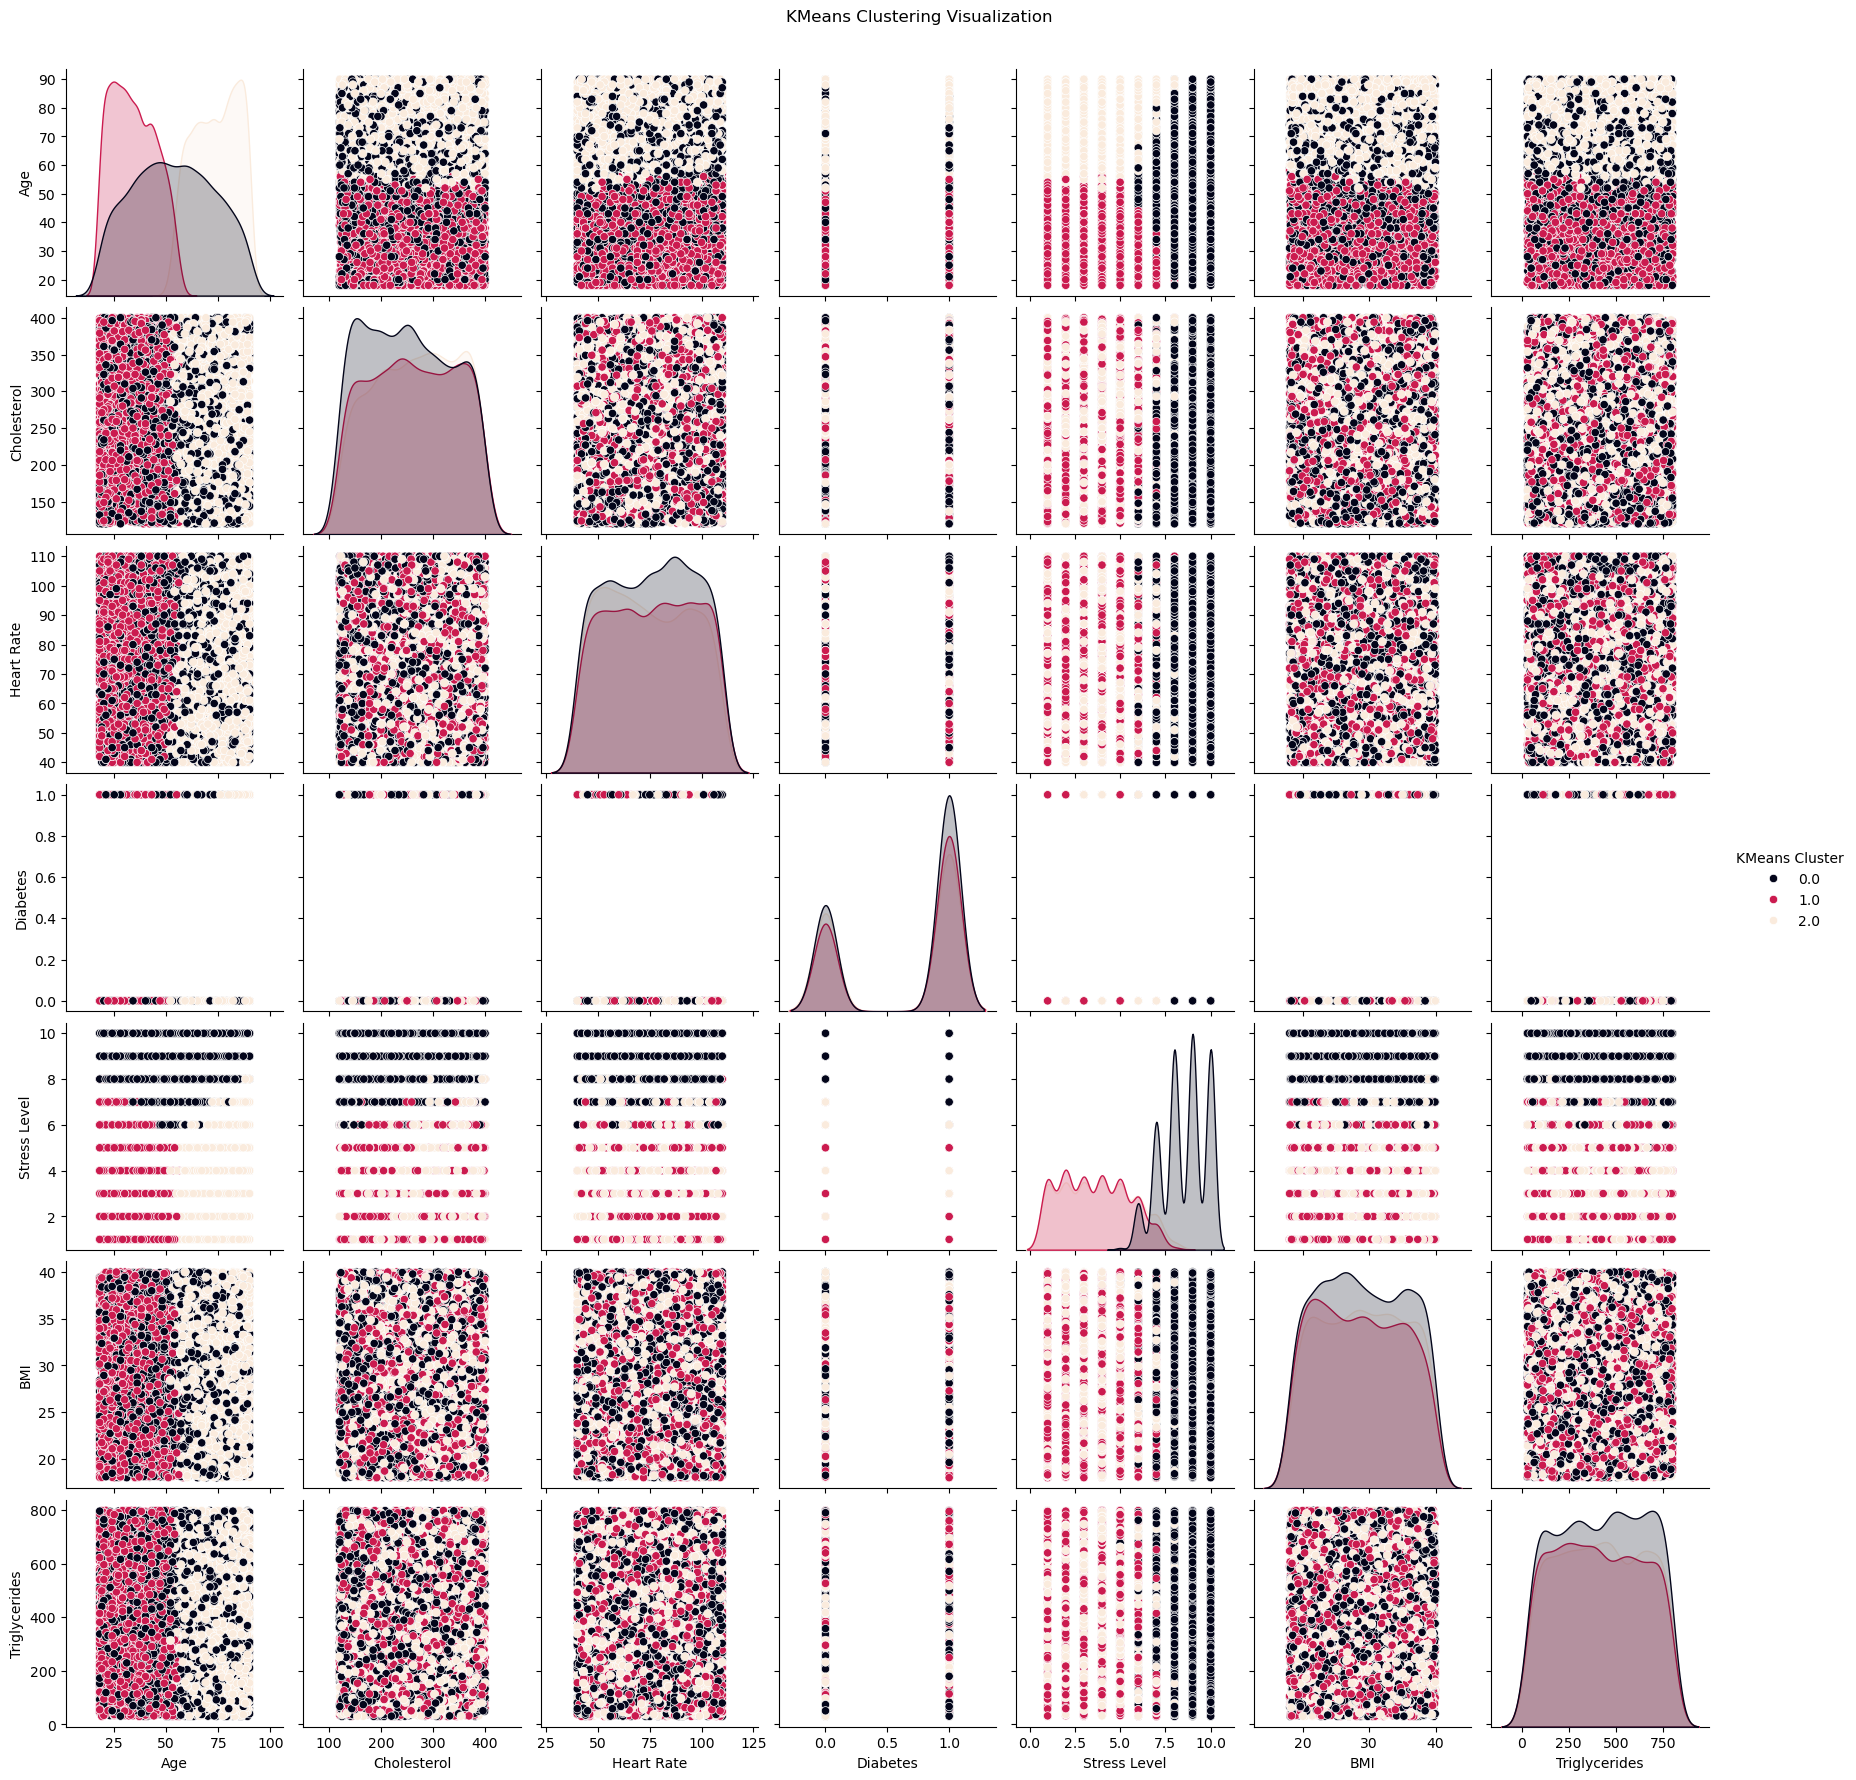

In [20]:
# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(x_scaled)
df.loc[x.index, 'KMeans Cluster'] = clusters_kmeans

# Visualize clusters with pairplot for KMeans
sns.pairplot(df.loc[x.index], vars=x, hue='KMeans Cluster', palette='rocket', diag_kind='kde')
plt.suptitle("KMeans Clustering Visualization", y=1.02)
plt.show()